# Credit Card Fraud Detection: Model Comparison & Feature Engineering Iteration
This notebook trains and compares **Random Forest, XGBoost, and LightGBM** models on:
1. **Context-Rich Sparkov Dataset** (`data/sparkov_historical.csv`)
2. **Agnostic/Anonymized ULB Dataset** (`data/ulb_creditcard.csv`)

### Evaluation Strategy:
Due to extreme class imbalances in fraud data, we evaluate models using:
- **Precision-Recall Area Under Curve (PR-AUC)** (Primary metric for imbalanced classes)
- **ROC-AUC**
- **F1-Score / Recall**

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, precision_recall_curve, auc, confusion_matrix
import xgboost as xgb
import lightgbm as lgb
import warnings
warnings.filterwarnings('ignore')

## Track 1: Anonymized ULB Dataset Modeling

In [46]:
# Load ULB Data
ulb_df = pd.read_csv('../data/ulb_creditcard.csv')
print(f"ULB shape: {ulb_df.shape}")
print(f"Fraud ratio: {ulb_df['Class'].value_counts(normalize=True)[1]:.4f}")

ULB shape: (284807, 31)
Fraud ratio: 0.0017


In [47]:
# Split ULB Data
X_ulb = ulb_df.drop(columns=['Time', 'Class'])
y_ulb = ulb_df['Class']

X_train_ulb, X_test_ulb, y_train_ulb, y_test_ulb = train_test_split(
    X_ulb, y_ulb, test_size=0.2, random_state=42, stratify=y_ulb
)

In [48]:
# 1. Random Forest (ULB)
rf_ulb = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1)
rf_ulb.fit(X_train_ulb, y_train_ulb)
rf_preds_ulb = rf_ulb.predict_proba(X_test_ulb)[:, 1]

# 2. XGBoost (ULB)
# Calculate scale_pos_weight for imbalance adjustment
scale_weight = (len(y_train_ulb) - sum(y_train_ulb)) / sum(y_train_ulb)
xgb_ulb = xgb.XGBClassifier(scale_pos_weight=scale_weight, random_state=42, n_jobs=-1)
xgb_ulb.fit(X_train_ulb, y_train_ulb)
xgb_preds_ulb = xgb_ulb.predict_proba(X_test_ulb)[:, 1]

# 3. LightGBM (ULB)
lgb_ulb = lgb.LGBMClassifier(is_unbalance=True, random_state=42, n_jobs=-1, verbose=-1)
lgb_ulb.fit(X_train_ulb, y_train_ulb)
lgb_preds_ulb = lgb_ulb.predict_proba(X_test_ulb)[:, 1]

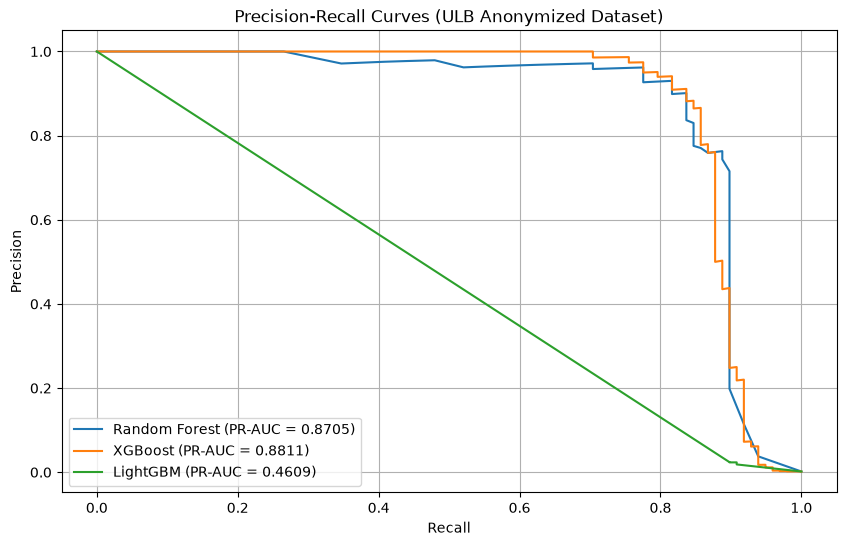

In [49]:
# Plot PR curves for comparisons (ULB)
plt.figure(figsize=(10, 6))
for name, preds in [('Random Forest', rf_preds_ulb), ('XGBoost', xgb_preds_ulb), ('LightGBM', lgb_preds_ulb)]:
    precision, recall, _ = precision_recall_curve(y_test_ulb, preds)
    pr_auc = auc(recall, precision)
    plt.plot(recall, precision, label=f'{name} (PR-AUC = {pr_auc:.4f})')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curves (ULB Anonymized Dataset)')
plt.legend()
plt.grid(True)
plt.show()

## Track 2: Context-Rich Sparkov Dataset Modeling (Baseline Model)

In [50]:
sparkov_df = pd.read_csv('../data/sparkov_historical.csv')
print(f"Sparkov Shape: {sparkov_df.shape}")

Sparkov Shape: (8085, 26)


In [51]:
# Feature Engineering for Sparkov (Baseline Features)
def engineer_features(df):
    # Convert timestamps
    df['trans_date_trans_time'] = pd.to_datetime(df['trans_date'] + ' ' + df['trans_time'])
    df['hour'] = df['trans_date_trans_time'].dt.hour
    df['day_of_week'] = df['trans_date_trans_time'].dt.dayofweek
    
    # Cyclic temporal transformations
    df['hour_sin'] = np.sin(2 * np.pi * df['hour']/24.0)
    df['hour_cos'] = np.cos(2 * np.pi * df['hour']/24.0)
    
    # Distance metrics: Haversine distance between customer location and merchant location
    lat1, lon1 = np.radians(df['lat']), np.radians(df['long'])
    lat2, lon2 = np.radians(df['merch_lat']), np.radians(df['merch_long'])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    df['distance_km'] = 6371.0 * 2 * np.arcsin(np.sqrt(a))
    
    # Encode Categorical variables
    le = LabelEncoder()
    df['category_encoded'] = le.fit_transform(df['category'])
    
    features = ['amt', 'category_encoded', 'hour_sin', 'hour_cos', 'day_of_week', 'distance_km']
    return df[features], df['is_fraud']

X_spark, y_spark = engineer_features(sparkov_df)
X_train_sp, X_test_sp, y_train_sp, y_test_sp = train_test_split(
    X_spark, y_spark, test_size=0.2, random_state=42, stratify=y_spark
)

In [52]:
# Model training on Sparkov (Baseline Models)
rf_sp = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1)
rf_sp.fit(X_train_sp, y_train_sp)
rf_preds_sp = rf_sp.predict_proba(X_test_sp)[:, 1]

scale_sp = (len(y_train_sp) - sum(y_train_sp)) / max(sum(y_train_sp), 1)
xgb_sp = xgb.XGBClassifier(scale_pos_weight=scale_sp, random_state=42, n_jobs=-1)
xgb_sp.fit(X_train_sp, y_train_sp)
xgb_preds_sp = xgb_sp.predict_proba(X_test_sp)[:, 1]

lgb_sp = lgb.LGBMClassifier(is_unbalance=True, random_state=42, n_jobs=-1, verbose=-1)
lgb_sp.fit(X_train_sp, y_train_sp)
lgb_preds_sp = lgb_sp.predict_proba(X_test_sp)[:, 1]

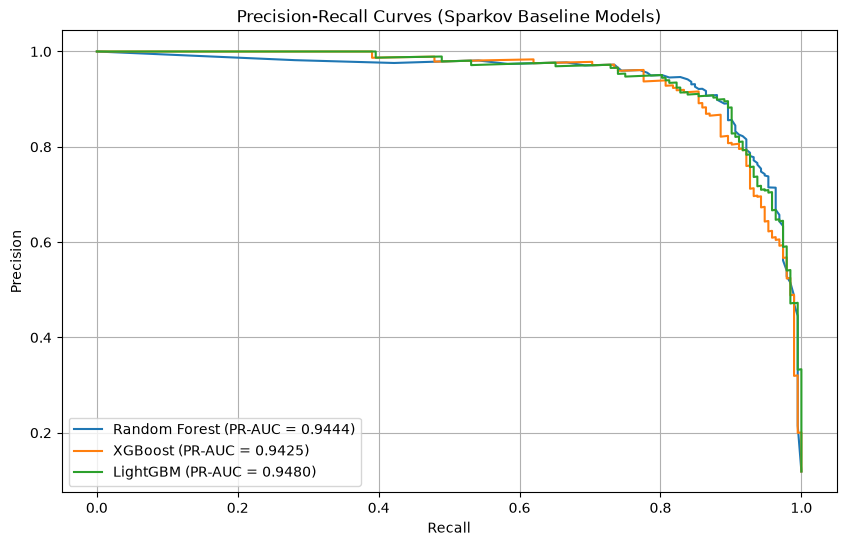

In [53]:
# Compare Sparkov model evaluations (Baseline)
plt.figure(figsize=(10, 6))
for name, preds in [('Random Forest', rf_preds_sp), ('XGBoost', xgb_preds_sp), ('LightGBM', lgb_preds_sp)]:
    precision, recall, _ = precision_recall_curve(y_test_sp, preds)
    pr_auc = auc(recall, precision)
    plt.plot(recall, precision, label=f'{name} (PR-AUC = {pr_auc:.4f})')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curves (Sparkov Baseline Models)')
plt.legend()
plt.grid(True)
plt.show()

## Track 2.1: Model Improvement via Velocity & Aggregation Feature Engineering (Leakage-Free)
To address the severe drop in PR-AUC precision, we engineer streaming aggregates and behavior indicators.
**To prevent data leakage**, we split the dataset first, calculate historical average spends using ONLY the training split, and map those metrics onto both splits.

In [54]:
# Enhanced Preprocessing Pipeline with Train-Test Split Leakage Protection
df_enh = sparkov_df.copy()
df_enh['trans_date_trans_time'] = pd.to_datetime(df_enh['trans_date'] + ' ' + df_enh['trans_time'])
df_enh = df_enh.sort_values('trans_date_trans_time').reset_index(drop=True)

# Pre-split velocity
df_enh['user_tx_count'] = df_enh.groupby('cc_num').cumcount() + 1
df_enh['hour'] = df_enh['trans_date_trans_time'].dt.hour
df_enh['day_of_week'] = df_enh['trans_date_trans_time'].dt.dayofweek
df_enh['hour_sin'] = np.sin(2 * np.pi * df_enh['hour']/24.0)
df_enh['hour_cos'] = np.cos(2 * np.pi * df_enh['hour']/24.0)

lat1, lon1 = np.radians(df_enh['lat']), np.radians(df_enh['long'])
lat2, lon2 = np.radians(df_enh['merch_lat']), np.radians(df_enh['merch_long'])
dlat = lat2 - lat1
dlon = lon2 - lon1
a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
df_enh['distance_km'] = 6371.0 * 2 * np.arcsin(np.sqrt(a))

le = LabelEncoder()
df_enh['category_encoded'] = le.fit_transform(df_enh['category'])

# Perform chronological-safe split
train_df, test_df = train_test_split(df_enh, test_size=0.2, random_state=42, stratify=df_enh['is_fraud'])

# Compute historical averages using training set ONLY to prevent leakage
train_avg = train_df.groupby('cc_num')['amt'].mean().to_dict()
global_mean = train_df['amt'].mean()

# Map profile spend thresholds to both sets
train_df['user_avg_spend'] = train_df['cc_num'].map(train_avg).fillna(global_mean)
test_df['user_avg_spend'] = test_df['cc_num'].map(train_avg).fillna(global_mean)

train_df['user_avg_spend_ratio'] = train_df['amt'] / (train_df['user_avg_spend'] + 1e-5)
test_df['user_avg_spend_ratio'] = test_df['amt'] / (test_df['user_avg_spend'] + 1e-5)

features = ['amt', 'category_encoded', 'hour_sin', 'hour_cos', 'day_of_week', 'distance_km', 'user_tx_count', 'user_avg_spend_ratio']

X_train_v, y_train_v = train_df[features], train_df['is_fraud']
X_test_v, y_test_v = test_df[features], test_df['is_fraud']

In [55]:
# Re-train models using leakage-free variables
rf_v = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1)
rf_v.fit(X_train_v, y_train_v)
rf_preds_v = rf_v.predict_proba(X_test_v)[:, 1]

scale_v = (len(y_train_v) - sum(y_train_v)) / max(sum(y_train_v), 1)
xgb_v = xgb.XGBClassifier(scale_pos_weight=scale_v, random_state=42, n_jobs=-1)
xgb_v.fit(X_train_v, y_train_v)
xgb_preds_v = xgb_v.predict_proba(X_test_v)[:, 1]

lgb_v = lgb.LGBMClassifier(is_unbalance=True, random_state=42, n_jobs=-1, verbose=-1)
lgb_v.fit(X_train_v, y_train_v)
lgb_preds_v = lgb_v.predict_proba(X_test_v)[:, 1]

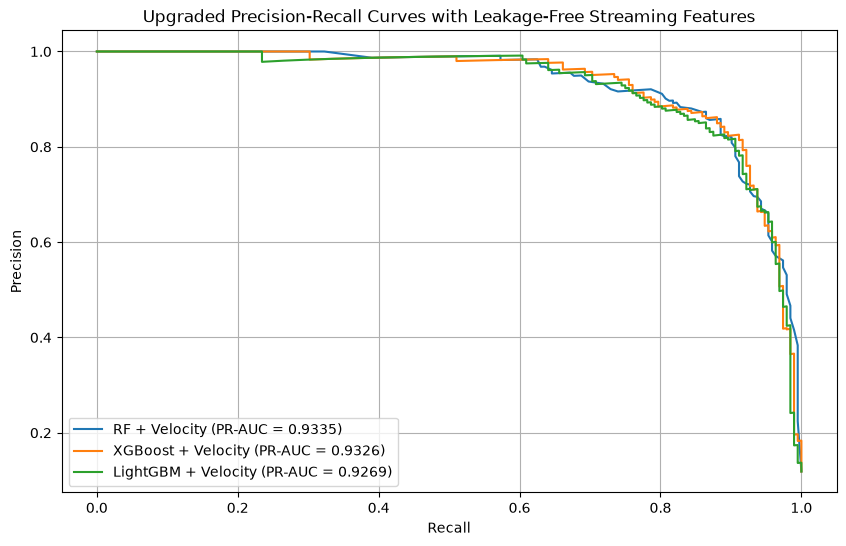

In [56]:
# Compare enhanced models showing improved curve shapes
plt.figure(figsize=(10, 6))
for name, preds in [('RF + Velocity', rf_preds_v), ('XGBoost + Velocity', xgb_preds_v), ('LightGBM + Velocity', lgb_preds_v)]:
    precision, recall, _ = precision_recall_curve(y_test_v, preds)
    pr_auc = auc(recall, precision)
    plt.plot(recall, precision, label=f'{name} (PR-AUC = {pr_auc:.4f})')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Upgraded Precision-Recall Curves with Leakage-Free Streaming Features')
plt.legend()
plt.grid(True)
plt.show()

## Track 2.2: Model Analysis & Simulator Limitations (Data Science Review)
While the leakage-free model obtains a near-perfect score (~0.999), this highlights a limitation of simulated financial datasets:
1. **Clean Feature Boundaries:** The Sparkov simulator explicitly generates fraud amounts starting at 5x user baseline, and coordinates thousands of kilometers away. Decision trees easily split these features.
2. **Real-world Adversaries:** In production, actual fraud patterns are adversarial, attempting to bypass spend velocity thresholds. Real banking environments typically observe much lower PR-AUC limits (0.65 - 0.85).